# 024 逻辑回归与softmax分类

## Goal
从logits、概率、负对数似然到批次梯度，核对完整NumPy分类闭环。合成固定9训练/6测试点，不是真实性能证据。先修023、017、019、021。

## Setup
在本单元目录重启内核，顺序运行。第一格核对原始输入与五份默认结果摘要；本图文只解释默认配置，自定义结果另存。训练只用NumPy，稳定参照用SciPy；无网络、GPU或付费调用。

In [1]:
from pathlib import Path
import math,sys
import numpy as np
from scipy.special import softmax,log_softmax,expit
from IPython.display import display,Image
import experiment as ex
ex.require_teaching_inputs()
print("Python",sys.version.split()[0],"NumPy",np.__version__)

Python 3.12.14 NumPy 2.3.5


## Steps
### 1 二分类手算
零参数、y=1的单例损失log2、logit梯度−0.5。对x=(2,−1)并更新偏置，步长0.2后z=0.6。

In [2]:
loss,g=ex.binary_loss_gradient([0.],[1])
assert math.isclose(loss,math.log(2)) and g[0]==-.5
w=np.array([0.,0.])-.2*g[0]*np.array([2.,-1.]);b=-.2*g[0]
z=np.array([2.,-1.])@w+b
assert math.isclose(z,.6)
print(w,b,z,ex.sigmoid([z]),ex.binary_loss_gradient([z],[1])[0])

[ 0.2 -0.1] 0.1 0.6 [0.64565631] 0.4374879504858856


### 2 避免正确类梯度抵消
z=37时直接sigmoid−1可能已是0，稳定补形式保留负的小量；z=1000依然可能真实超出float64表示范围。

In [3]:
direct=ex.sigmoid([37.])[0]-1
stable=ex.binary_loss_gradient([37.],[1])[1][0]
assert direct==0 and stable<0
print("direct",direct,"stable",stable)
print("z=1000",ex.binary_loss_gradient([1000.],[1]))

direct 0.0 stable -8.533047625744066e-17
z=1000 (0.0, array([-0.]))


### 3 三类手算与雅可比
一个logit增大影响所有类别；概率与logit梯度每行的和分别为1与0。

In [4]:
z=np.array([[math.log(2),0,0]])
loss,g,p=ex.multiclass_loss_gradient(z,[0])
np.testing.assert_allclose(p,[[.5,.25,.25]])
np.testing.assert_allclose(g,[[-.5,.25,.25]])
J=np.diag(p[0])-np.outer(p[0],p[0])
np.testing.assert_allclose(J.sum(axis=1),0,atol=1e-16)
print("loss",loss,"gradient",g,"Jacobian",J)

loss 0.6931471805599453 gradient [[-0.5   0.25  0.25]] Jacobian [[ 0.25   -0.125  -0.125 ]
 [-0.125   0.1875 -0.0625]
 [-0.125  -0.0625  0.1875]]


### 4 极端logits保留log信息
下溢的概率0不能直接取log；从log_softmax取损失。

probability [[0.26894142 0.73105858 0.        ]] loss 2001.3132616875182 gradient [[ 0.26894142  0.73105858 -1.        ]]


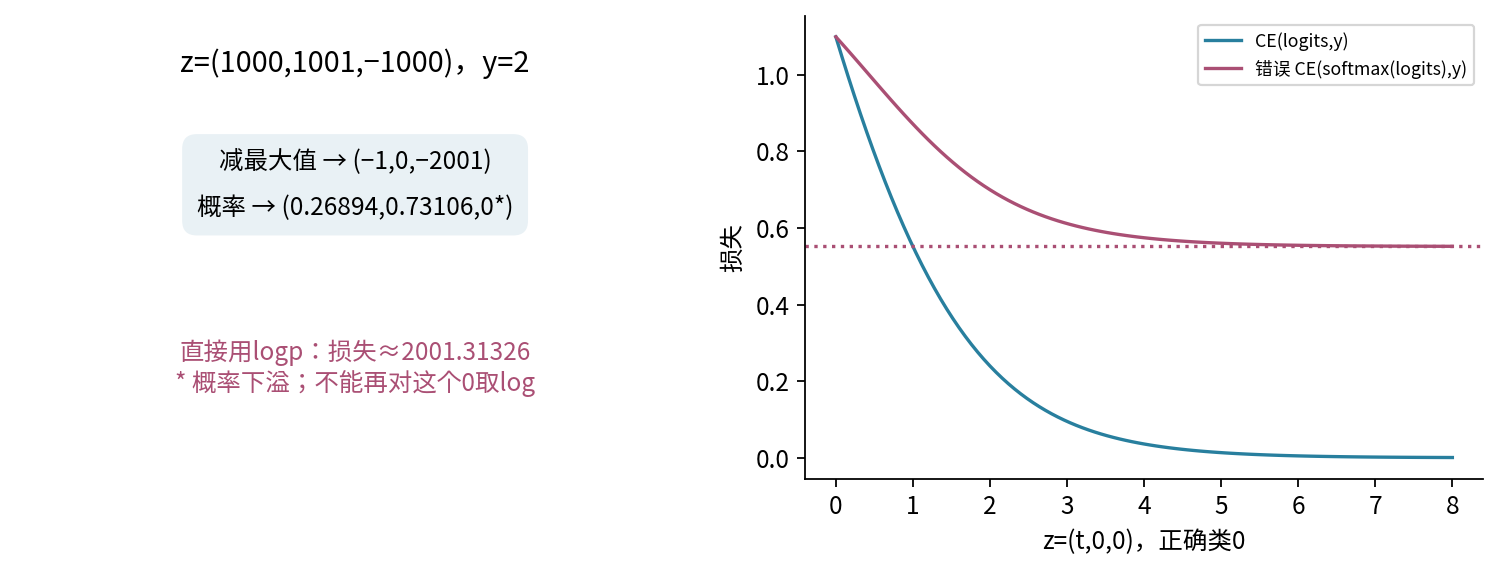

In [5]:
z=np.array([[1000.,1001.,-1000.]])
loss,g,p=ex.multiclass_loss_gradient(z,[2])
assert p[0,2]==0 and math.isfinite(loss)
np.testing.assert_allclose(ex.log_softmax(z),log_softmax(z,axis=1))
print("probability",p,"loss",loss,"gradient",g)
display(Image(filename="figures/04_logits_loss.png",width=750))

### 5 批次轴与第一步
训练矩阵(9,3)，参数(3,3)，每行三个类别，标签(9,)。示范0.3一步与主配置0.25分开。

In [6]:
rows=ex.read_data(Path("data/classification.csv"));train=[r for r in rows if r[1]=="train"]
X=np.array([r[2] for r in train]);y=np.array([r[3] for r in train]);W=np.zeros((3,3))
loss,g,p=ex.objective(X,y,W,0)
expected=np.array([[5/9,-5/9,0],[5/27,5/27,-10/27],[0,0,0]])
np.testing.assert_allclose(g,expected,atol=1e-16)
print("shapes",X.shape,W.shape,p.shape,y.shape,"initial loss",loss)
print("demonstration step at0.3",W-.3*g)

shapes (9, 3) (3, 3) (9, 3) (9,) initial loss 1.0986122886681098
demonstration step at0.3 [[-0.16666667  0.16666667  0.        ]
 [-0.05555556 -0.05555556  0.11111111]
 [ 0.          0.          0.        ]]


### 6 sum和mean
只比较数据损失、λ=0；sum学习率除N后一步相同。

In [7]:
W=np.array([[.1,-.2,.1],[.2,0.,-.2],[0.,.1,-.1]])
mean,gm,_=ex.objective(X,y,W,0,"mean")
summed,gs,_=ex.objective(X,y,W,0,"sum")
np.testing.assert_allclose(gs,len(X)*gm)
np.testing.assert_allclose(W-.25*gm,W-(.25/len(X))*gs)
print("sum/mean ratio",summed/mean)

sum/mean ratio 9.0


### 7 一个坐标的中心差分
中等参数尺度、保持同一mean与正则项。

In [8]:
loss,g,p=ex.objective(X,y,W,.03);h=1e-5;numeric=np.zeros_like(W)
for idx in np.ndindex(W.shape):
    plus=W.copy();minus=W.copy();plus[idx]+=h;minus[idx]-=h
    numeric[idx]=(ex.objective(X,y,plus,.03)[0]-ex.objective(X,y,minus,.03)[0])/(2*h)
assert np.max(np.abs(numeric-g))<1e-9
print("max gradient error",np.max(np.abs(numeric-g)))

max gradient error 1.165190166574348e-11


### 8 实际运行400步
预定η=0.25、λ=0.03，测试仅报告冻结参数的结果；另有无正则一维二分类路径。

[[-1.6417289617941517, 1.6417289617941517, 3.0680322237881726e-18], [-0.6176949487633434, -0.6176949487633434, 1.2353898975266868], [0.19842026041269054, 0.19842026041269054, -0.3968405208253811]]
{'train': {'rows': 9, 'mean_ce': 0.12365797139822707, 'correct': 9, 'accuracy': 1.0}, 'test': {'rows': 6, 'mean_ce': 0.06898233157861906, 'correct': 6, 'accuracy': 1.0}}
{'step': 400, 'weight': 4.00124018242324, 'mean_bce': 0.009231105463311136, 'gradient': -0.009316678685290954}


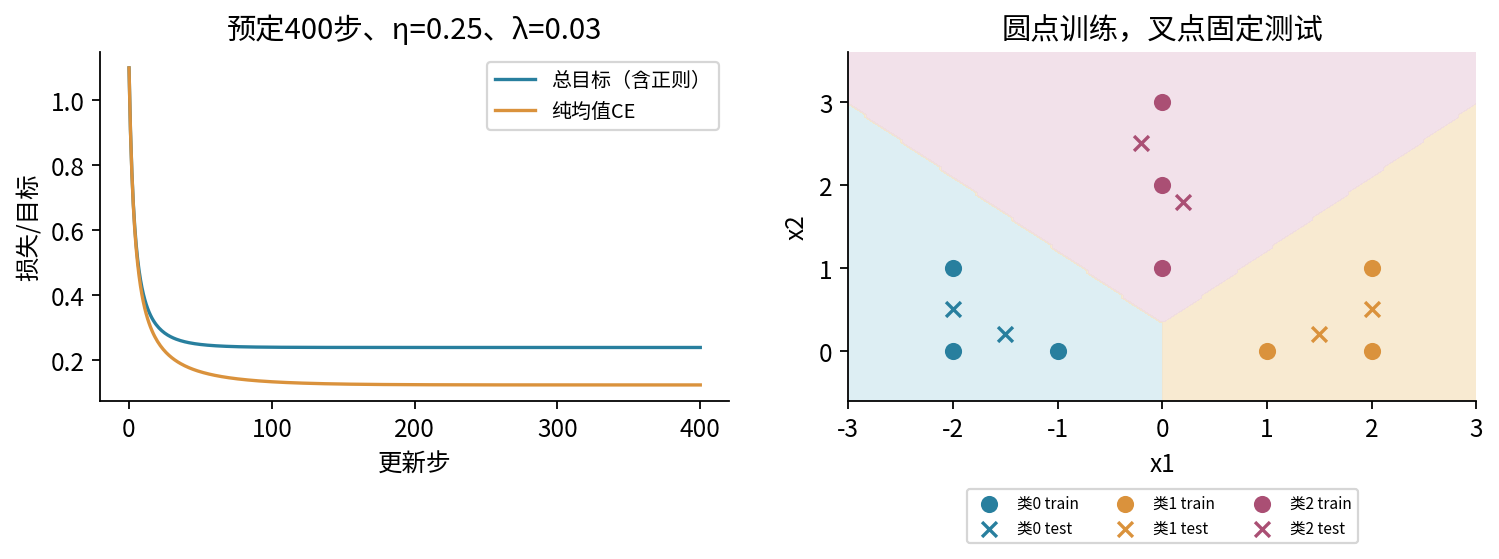

In [9]:
result=ex.run(Path("notebook_outputs"))
print(result["weights"])
print(result["metrics"])
print(result["binary_final"])
display(Image(filename="figures/07_training_boundary.png",width=750))

### 9 错误双softmax不是相同目标
将概率当成logits会再次归一化。分类排序可不变，损失却改变。

In [10]:
z=np.array([[8.,0.,0.]])
direct,g,p=ex.multiclass_loss_gradient(z,[0])
wrong=ex.multiclass_loss_gradient(p,[0])[0]
assert direct<.001 and wrong>.55
print("correct loss",direct,"wrong loss",wrong,"wrong limit",math.log(math.e+2)-1)

correct loss 0.0006707002860752102 wrong loss 0.5518711422532396 wrong limit 0.5514447139320509


### 10 可分数据没有有限零损失解
准确率停止变化与参数/损失收敛不同。

{'step': 0, 'weight': 0.0, 'mean_bce': 0.6931471805599453, 'gradient': -0.75} {'step': 1, 'weight': 0.1875, 'mean_bce': 0.5634542768477174, 'gradient': -0.6339643240536232} {'step': 400, 'weight': 4.00124018242324, 'mean_bce': 0.009231105463311136, 'gradient': -0.009316678685290954}


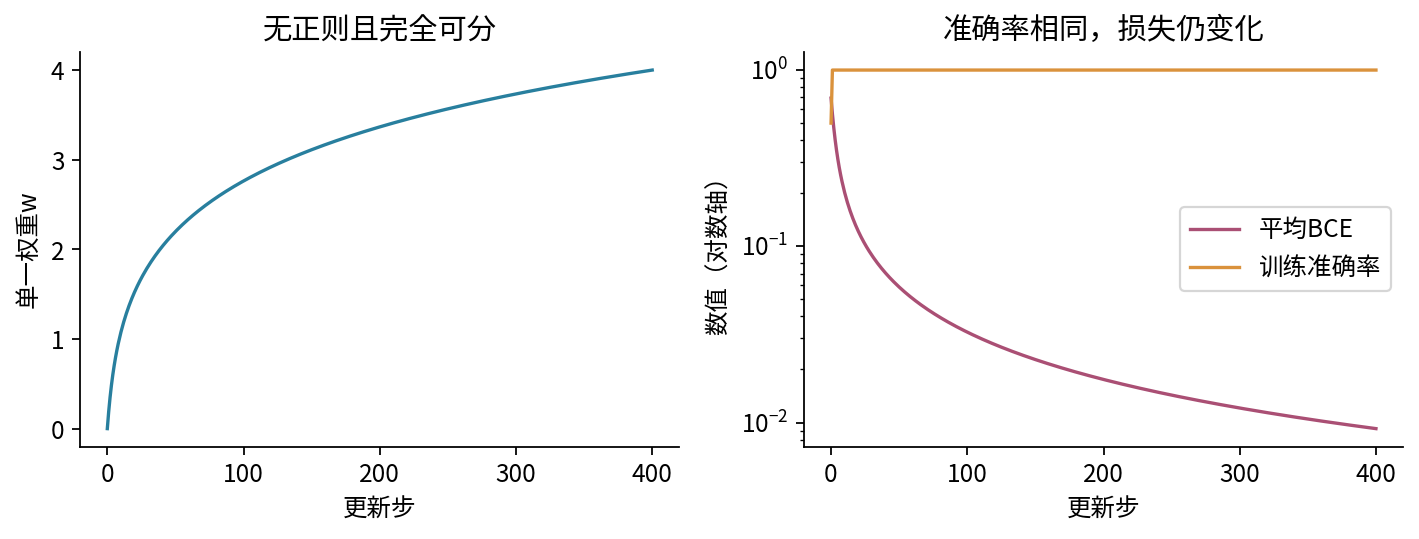

In [11]:
path=ex.binary_path(400,.25)
assert all(b["weight"]>a["weight"] for a,b in zip(path,path[1:]))
assert all(b["mean_bce"]<a["mean_bce"] for a,b in zip(path,path[1:]))
print(path[0],path[1],path[-1])
display(Image(filename="figures/08_separation.png",width=750))

## Checks
### 11 错误类型和shape必须拒绝
不能默许广播或布尔标签改变任务。

In [12]:
for call in (lambda:ex.multiclass_loss_gradient([[0,0]],[True]),lambda:ex.multiclass_loss_gradient([[0,0]],[[0]])):
    try:call()
    except ValueError as error:print("rejected",error)
    else:raise AssertionError("bad label accepted")

rejected boolean labels forbidden
rejected integer label vector with exact shape and range required


### 12 五个文件完全一致
本次和脚本都是默认输入；实际运行结果不是预写截图。

In [13]:
for name in ("results.json","training.csv","binary_path.csv","predictions.csv","environment.json"):
    assert (Path("outputs")/name).read_bytes()==(Path("notebook_outputs")/name).read_bytes()
print("5 output files byte-identical")

5 output files byte-identical


## Next Steps
完成正文15题及实验A至D，说明每个公式的对象、shape、归约和数值范围。三类9/9与6/6全对仅为固定合成点结果，不保证真实泛化、校准或唯一参数。

实际执行真实InProcessKernel；未测试全新Anaconda、浏览器Jupyter、socket内核、跨平台或GPU。PyTorch仅查官方接口文档，没有执行框架训练。